# AI Budget Tracker with Smart Financial Insights
### ITM-360 Artificial Intelligence - Full Pipeline
---
**System Workflow (Proposal Section IV.D):**
1. User records income and expenses
2. Expense data is processed and classified by Model 1
3. Data is aggregated by category and time
4. Model 2 predicts future spending *(on-demand, per-user - no pre-training)*
5. Model 3 generates financial insights and overspending warnings
6. Results are displayed using tables and charts

In [35]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import re
import sys
from pathlib import Path
from scipy.sparse import hstack
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("Libraries imported!")

Libraries imported!


In [36]:
# Cell 2: Load Model 1 - Expense Classifier
# clean_text was pickled as __main__.clean_text in the original notebook.
# Define it here AND inject into __main__ BEFORE joblib.load() runs.

def clean_text(text):
    import re
    text = str(text).lower()
    text = re.sub(r'\b(gasoline|petrol|fuel|diesel)\b', 'petrol', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    return text.strip()

sys.modules['__main__'].clean_text = clean_text

MODEL_PATH = Path('tfidf_expense_classifier.joblib')
artifact   = joblib.load(MODEL_PATH)
vectorizer   = artifact['vectorizer']
scaler       = artifact['scaler']
clf          = artifact['model']
le           = artifact['label_encoder']
num_features = artifact['num_features']
print('Model 1 (TF-IDF + Logistic Regression) loaded!')
print(f'  Raw categories: {list(le.classes_)}')

Model 1 (TF-IDF + Logistic Regression) loaded!
  Raw categories: ['Childcare', 'Education', 'Entertainment', 'Food', 'Freelance', 'Healthcare', 'Housing', 'Investment', 'Misc', 'Other Income', 'Rental', 'Salary', 'Shopping', 'Transport', 'Utilities']


In [37]:
# Cell 3: classify_transaction + proposal category mapping
# Proposal Section IV.A: Food, Transportation, Entertainment, Utilities, Rent, Other

CATEGORY_MAP = {
    'Food'          : 'Food',
    'Transport'     : 'Transportation',
    'Entertainment' : 'Entertainment',
    'Utilities'     : 'Utilities',
    'Rent'          : 'Rent',
    'Shopping'      : 'Other',
    'Healthcare'    : 'Other',
    'Education'     : 'Other',
    'Misc'          : 'Other',
    'Other'         : 'Other',
    'Housing'       : 'Rent',
    'Childcare'     : 'Other',
    'Investment'    : 'Other',
}

def classify_transaction(description, amount=0.0, transaction_type='Expense', date_str='2026-01-01'):
    """Returns (proposal_category, raw_model_category)."""
    cleaned     = clean_text(description)
    parsed_date = pd.to_datetime(date_str)
    type_value  = 1 if str(transaction_type).lower() == 'income' else 0
    dow         = int(parsed_date.dayofweek)
    is_weekend  = 1 if dow in [5, 6] else 0
    row = pd.DataFrame([{'Amount': float(amount), 'Type': type_value,
                         'Month': int(parsed_date.month), 'Day_of_Week': dow, 'Is_Weekend': is_weekend}])
    text_vec   = vectorizer.transform([cleaned])
    num_scaled = scaler.transform(row)
    features   = hstack([text_vec, num_scaled])
    raw_cat    = le.inverse_transform([clf.predict(features)[0]])[0]
    return CATEGORY_MAP.get(raw_cat, 'Other'), raw_cat

tests = [
    ('Bought rice and vegetables at market', 4.5),
    ('Grab ride to work', 3.0),
    ('Netflix subscription', 15.99),
    ('Electricity bill payment', 30.0),
    ('Rent payment', 200.0),
    ('Hospital checkup', 20.0),
]
print('Model 1 sanity check:')
print(f"  {'Description':<42} {'Raw':>14}  {'Mapped':>16}")
print('  ' + '-'*76)
for desc, amt in tests:
    mapped, raw = classify_transaction(desc, amt)
    print(f'  {desc:<42} {raw:>14}  {mapped:>16}')

Model 1 sanity check:
  Description                                           Raw            Mapped
  ----------------------------------------------------------------------------
  Bought rice and vegetables at market                 Food              Food
  Grab ride to work                               Transport    Transportation
  Netflix subscription                            Utilities         Utilities
  Electricity bill payment                        Utilities         Utilities
  Rent payment                                      Housing              Rent
  Hospital checkup                               Healthcare             Other


---
## Step 1 - User Records Income and Expenses

Upload a CSV with columns: `date`, `description`, `amount`, `type`

| date | description | amount | type |
|------|-------------|--------|------|
| 2024-01-01 | Monthly salary | 500 | Income |
| 2024-01-05 | Bought rice at market | 4.5 | Expense |

- **Income** rows: summed per month as budget reference
- **Expense** rows: classified by Model 1

In [38]:
# Cell 5: Step 1 - User Records Income and Expenses
CSV_PATH = 'user_transactions.csv'

# DEMO DATA - replace with: df_raw = pd.read_csv(CSV_PATH)
demo_data = {
    'date': [
        '2024-01-01','2024-02-01','2024-03-01','2024-04-01','2024-05-01','2024-06-01',
        '2024-01-05','2024-01-08','2024-01-12','2024-01-18','2024-01-22','2024-01-28',
        '2024-02-03','2024-02-07','2024-02-14','2024-02-19','2024-02-23','2024-02-27',
        '2024-03-02','2024-03-06','2024-03-11','2024-03-16','2024-03-21','2024-03-29',
        '2024-04-04','2024-04-09','2024-04-13','2024-04-18','2024-04-24','2024-04-30',
        '2024-05-02','2024-05-08','2024-05-14','2024-05-20','2024-05-25','2024-05-31',
        '2024-06-03','2024-06-10','2024-06-15','2024-06-20','2024-06-25','2024-06-30',
    ],
    'description': [
        'Monthly salary','Monthly salary','Monthly salary',
        'Monthly salary','Monthly salary','Monthly salary',
        'Bought rice and vegetables at market','Grab ride to work','Netflix subscription',
        'Electricity bill','Coffee at Brown Coffee','Bought clothes at AEON Mall',
        'Lunch at local restaurant','Bus fare to university','Cinema ticket',
        'Water bill','Snacks at 7-Eleven','Fuel at Caltex',
        'Dinner at BBQ restaurant','Tuk tuk to Orussey Market','Spotify subscription',
        'Internet bill','Bought jacket at Lucky Mall','Groceries at Lucky Supermarket',
        'Breakfast noodles at local shop','Motorbike fuel at PTT','Hospital checkup',
        'Phone top up Cellcard','Books at monument books','Rent payment',
        'Rice and fish at market','Grab ride to airport','Gaming top up Steam',
        'Electric bill','Milk tea at Chatime','Rent payment',
        'Lunch fried rice near office','Tuk tuk ride to BKK market','Amazon Prime subscription',
        'Water bill payment','Bought snacks Lucky Mart','Petrol at Tela station',
    ],
    'amount': [
        500,500,500,500,500,500,
        4.5,3.0,15.99,30.0,2.5,45.0,
        6.0,1.5,8.0,12.0,2.0,5.0,
        10.0,2.5,9.99,25.0,38.0,22.0,
        2.0,4.0,20.0,5.0,18.0,200.0,
        5.5,7.0,10.0,28.0,2.75,200.0,
        3.0,3.5,8.99,12.0,4.0,6.0,
    ],
    'type': ['Income']*6 + ['Expense']*36
}
df_raw = pd.DataFrame(demo_data)
# df_raw = pd.read_csv(CSV_PATH)

df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw['type'] = df_raw['type'].str.strip().str.title()
df_raw = df_raw.sort_values('date').reset_index(drop=True)

income_df  = df_raw[df_raw['type'] == 'Income'].copy()
expense_df = df_raw[df_raw['type'] == 'Expense'].copy()

print(f'Loaded {len(df_raw)} records - {len(income_df)} income | {len(expense_df)} expense')
print(f'Date range: {df_raw["date"].min().date()} to {df_raw["date"].max().date()}')
df_raw.head(10)

Loaded 42 records - 6 income | 36 expense
Date range: 2024-01-01 to 2024-06-30


,date,description,amount,type
0,2024-01-01,Monthly salary,500.00,Income
1,2024-01-05,Bought rice and vegetables at market,4.50,Expense
2,2024-01-08,Grab ride to work,3.00,Expense
3,2024-01-12,Netflix subscription,15.99,Expense
4,2024-01-18,Electricity bill,30.00,Expense
5,2024-01-22,Coffee at Brown Coffee,2.50,Expense
6,2024-01-28,Bought clothes at AEON Mall,45.00,Expense
7,2024-02-01,Monthly salary,500.00,Income
8,2024-02-03,Lunch at local restaurant,6.00,Expense
9,2024-02-07,Bus fare to university,1.50,Expense


---
## Step 2 - Model 1: Classify Expense Transactions

In [39]:
# Cell 7: Step 2 - Model 1 classifies every expense row
expense_df = expense_df.copy()
results = expense_df.apply(
    lambda r: classify_transaction(
        r['description'], r['amount'], 'Expense', str(r['date'].date())
    ), axis=1
)
expense_df['category']     = [x[0] for x in results]  # proposal-mapped
expense_df['category_raw'] = [x[1] for x in results]  # raw model output

print('All expense transactions classified!')
print('\nCategory distribution (proposal categories):')
print(expense_df['category'].value_counts().to_string())
print()
expense_df[['date','description','amount','category_raw','category']].head(12)

All expense transactions classified!

Category distribution (proposal categories):
category
Food              12
Transportation     8
Utilities          8
Other              4
Entertainment      2
Rent               2



,date,description,amount,category_raw,category
1,2024-01-05,Bought rice and vegetables at market,4.50,Food,Food
2,2024-01-08,Grab ride to work,3.00,Transport,Transportation
3,2024-01-12,Netflix subscription,15.99,Utilities,Utilities
4,2024-01-18,Electricity bill,30.00,Utilities,Utilities
5,2024-01-22,Coffee at Brown Coffee,2.50,Food,Food
6,2024-01-28,Bought clothes at AEON Mall,45.00,Shopping,Other
8,2024-02-03,Lunch at local restaurant,6.00,Food,Food
9,2024-02-07,Bus fare to university,1.50,Transport,Transportation
10,2024-02-14,Cinema ticket,8.00,Entertainment,Entertainment
11,2024-02-19,Water bill,12.00,Utilities,Utilities


---
## Step 3 - Aggregate by Category and Time

In [40]:
# Cell 9: Step 3 - Aggregate by category and time
expense_df['month'] = expense_df['date'].dt.to_period('M')
income_df['month']  = income_df['date'].dt.to_period('M')

monthly_income  = income_df.groupby('month')['amount'].sum().rename('total_income')
monthly_expense = expense_df.groupby('month')['amount'].sum().rename('total_expenses')

monthly = pd.DataFrame({'total_income': monthly_income, 'total_expenses': monthly_expense}).fillna(0)
# Net Balance = Total Income - Total Expenses (Proposal Section IV.A)
monthly['net_balance'] = monthly['total_income'] - monthly['total_expenses']
monthly['month_dt']    = monthly.index.to_timestamp()
monthly = monthly.reset_index()

monthly_cat = expense_df.groupby(['month','category'])['amount'].sum().unstack(fill_value=0)
monthly_cat.index = monthly_cat.index.to_timestamp()

print('Monthly Financial Summary:')
print(f"  {'Month':<10} {'Income':>10} {'Expenses':>10} {'Net Balance':>12}")
print('  ' + '-'*46)
for _, r in monthly.iterrows():
    print(f"  {str(r['month']):<10} ${r['total_income']:>9,.2f} ${r['total_expenses']:>9,.2f} ${r['net_balance']:>11,.2f}")
print()
print('Spending by Category per Month:')
print(monthly_cat.to_string())

Monthly Financial Summary:
  Month          Income   Expenses  Net Balance
  ----------------------------------------------
  2024-01    $   500.00 $   100.99 $     399.01
  2024-02    $   500.00 $    34.50 $     465.50
  2024-03    $   500.00 $   107.49 $     392.51
  2024-04    $   500.00 $   249.00 $     251.00
  2024-05    $   500.00 $   253.25 $     246.75
  2024-06    $   500.00 $    37.49 $     462.51

Spending by Category per Month:
category    Entertainment   Food  Other   Rent  Transportation  Utilities
month                                                                    
2024-01-01            0.0   7.00   45.0    0.0             3.0      45.99
2024-02-01            8.0   8.00    0.0    0.0             6.5      12.00
2024-03-01            0.0  32.00   38.0    0.0             2.5      34.99
2024-04-01            0.0  20.00   25.0  200.0             4.0       0.00
2024-05-01           10.0   8.25    0.0  200.0             7.0      28.00
2024-06-01            0.0   7.00    0

---
## Step 4 - Model 2: Per-User Spending Prediction
> **On-demand training only** - no pre-trained model stored. Trained fresh from each user's own historical data using walk-forward validation.

In [41]:
# Cell 11: Step 4 - Model 2 forecasting functions
def rolling_average_forecast(series, window=2):
    return series.iloc[-window:].mean()

def weighted_recent_forecast(series, window=2):
    recent  = series.iloc[-window:].values
    weights = np.arange(1, window + 1)
    return np.average(recent, weights=weights)

def find_best_window(series, windows=[2, 3, 4, 5]):
    """Walk-forward validation - finds window + model with lowest MAE."""
    best_window, best_mae, best_model = 2, float('inf'), 'RA'
    for w in windows:
        if w >= len(series): continue
        ra_preds, wt_preds, actuals = [], [], []
        for t in range(w, len(series)):
            hist = series.iloc[:t]
            ra_preds.append(rolling_average_forecast(hist, w))
            wt_preds.append(weighted_recent_forecast(hist, w))
            actuals.append(series.iloc[t])
        ra_mae = mean_absolute_error(actuals, ra_preds)
        wt_mae = mean_absolute_error(actuals, wt_preds)
        if ra_mae < best_mae:
            best_mae, best_window, best_model = ra_mae, w, 'RA'
        if wt_mae < best_mae:
            best_mae, best_window, best_model = wt_mae, w, 'WT'
    return best_window, best_model, best_mae

print('Model 2 forecasting functions ready!')

Model 2 forecasting functions ready!


In [42]:
# Cell 12: Step 4 - On-Demand Per-User Training
spending_series = monthly.set_index('month_dt')['total_expenses']

best_window, best_model_name, best_mae = find_best_window(spending_series)

if best_model_name == 'WT':
    next_pred = weighted_recent_forecast(spending_series, best_window)
else:
    next_pred = rolling_average_forecast(spending_series, best_window)

next_month   = spending_series.index[-1] + pd.DateOffset(months=1)
recent_slope = spending_series.iloc[-1] - spending_series.iloc[-best_window]
trend        = 'Upward' if recent_slope > 20 else ('Downward' if recent_slope < -20 else 'Stable')

print('Model 2 - Spending Prediction')
print('  Trained on    : this user only (on-demand, no pre-training)')
print(f'  Algorithm     : {"Weighted Recent" if best_model_name == "WT" else "Rolling Average"}')
print(f'  Best window   : {best_window} months')
print(f'  MAE           : ${best_mae:.2f}')
print(f'  Spending trend: {trend}')
print()
print(f'  Next month forecast ({next_month.strftime("%Y-%m")}): ${next_pred:.2f}')

Model 2 - Spending Prediction
  Trained on    : this user only (on-demand, no pre-training)
  Algorithm     : Rolling Average
  Best window   : 5 months
  MAE           : $111.56
  Spending trend: Stable

  Next month forecast (2024-07): $136.35


---
## Step 5 - Model 3: Financial Insights and Overspending Detection
Rule-Based Inference System (Expert System) - Proposal Section IV.B

- **OVERSPENDING** - actual % of income exceeds threshold
- **WARNING** - actual % exceeds 85% of threshold
- **OK** - within budget

In [43]:
# Cell 14: Step 5 - Model 3 Rule-Based Inference Engine
# Budget thresholds from Proposal Section IV.B Model 3
BUDGET_RULES = {
    'Food'          : 25,
    'Transportation': 15,
    'Entertainment' : 10,
    'Utilities'     : 10,
    'Rent'          : 30,
    'Other'         : 10,
}
SAVINGS_RULE = 20  # savings >= 20% of income (proposal rule)

# User can override thresholds here
CUSTOM_RULES = {}  # e.g. {'Food': 20, 'Rent': 35}
for cat, val in CUSTOM_RULES.items():
    BUDGET_RULES[cat] = val


def run_inference_engine(cat_df, total_income, budget_rules, savings_rule):
    """Rule-Based Inference Engine (Model 3)."""
    insights      = []
    total_expense = cat_df['Total_Spent'].sum()
    savings       = total_income - total_expense
    savings_pct   = (savings / total_income * 100) if total_income > 0 else 0

    for _, row in cat_df.iterrows():
        cat   = row['Category']
        spent = row['Total_Spent']
        pct   = (spent / total_income * 100) if total_income > 0 else 0
        limit = budget_rules.get(cat, 10)

        if pct > limit:
            status  = 'OVERSPENDING'
            insight = (f'You spent {pct:.1f}% of your income on {cat}, '
                       f'which exceeds the recommended limit of {limit}%. '
                       f'Consider reducing {cat} by ${spent - total_income * limit / 100:,.2f}.')
        elif pct > limit * 0.85:
            status  = 'WARNING'
            insight = (f'{cat} is at {pct:.1f}% of income, '
                       f'approaching the {limit}% limit. Monitor closely.')
        else:
            status  = 'OK'
            insight = f'{cat} spending is healthy at {pct:.1f}% of income (limit: {limit}%).'

        insights.append({'Category': cat, 'Amount': spent,
                         'Pct_Income': round(pct, 2), 'Limit_Pct': limit,
                         'Status': status, 'Insight': insight})

    if savings_pct < savings_rule:
        insights.append({'Category': 'Savings', 'Amount': savings,
            'Pct_Income': round(savings_pct, 2), 'Limit_Pct': savings_rule,
            'Status': 'OVERSPENDING',
            'Insight': (f'Savings rate is only {savings_pct:.1f}%, below the recommended {savings_rule}%. '
                        f'Try to save at least ${total_income * savings_rule / 100:,.2f}/month.')})
    else:
        insights.append({'Category': 'Savings', 'Amount': savings,
            'Pct_Income': round(savings_pct, 2), 'Limit_Pct': savings_rule,
            'Status': 'OK',
            'Insight': (f'Great! Saving {savings_pct:.1f}% of income, '
                        f'meeting the recommended {savings_rule}% minimum.')})

    return pd.DataFrame(insights)


def generate_nlp_report(insight_df, total_income, total_expense, predicted_next, trend):
    """Template-based NLP report - Proposal Section IV Model 3."""
    savings     = total_income - total_expense
    savings_pct = savings / total_income * 100 if total_income > 0 else 0
    lines = [
        '=' * 60, '        SMART FINANCIAL INSIGHTS REPORT', '=' * 60, '',
        '[SUMMARY]',
        f'  Total Income   : ${total_income:>10,.2f}',
        f'  Total Expenses : ${total_expense:>10,.2f}',
        f'  Net Balance    : ${savings:>10,.2f}  ({savings_pct:.1f}%)',
        f'  Next Month Est.: ${predicted_next:>10,.2f}  ({trend})',
    ]
    oversp   = insight_df[insight_df['Status'] == 'OVERSPENDING']
    warnings = insight_df[insight_df['Status'] == 'WARNING']
    healthy  = insight_df[insight_df['Status'] == 'OK']
    if not oversp.empty:
        lines += ['', '[OVERSPENDING WARNINGS]'] + [f'  - {r["Insight"]}' for _, r in oversp.iterrows()]
    if not warnings.empty:
        lines += ['', '[NEAR LIMIT WARNINGS]']   + [f'  - {r["Insight"]}' for _, r in warnings.iterrows()]
    if not healthy.empty:
        lines += ['', '[HEALTHY CATEGORIES]']    + [f'  - {r["Insight"]}' for _, r in healthy.iterrows()]
    lines += ['', '[BUDGET RECOMMENDATIONS]']
    if savings_pct < SAVINGS_RULE:
        lines += [
            '  - Predicted expenses are high. Consider adjusting your budget.',
            f'  - Target savings: ${total_income * SAVINGS_RULE / 100:,.2f}/month',
            f'  - Current savings gap: ${total_income * SAVINGS_RULE / 100 - savings:,.2f}',
        ]
    else:
        lines.append('  - Your budget is well managed. Keep maintaining your saving habits!')
    lines.append('\n' + '=' * 60)
    return '\n'.join(lines)

print('Model 3 inference engine ready!')

Model 3 inference engine ready!


In [44]:
# Cell 15: Step 5 - Run Model 3 on latest month
latest_month     = monthly.iloc[-1]
total_income_m   = latest_month['total_income']
total_expense_m  = latest_month['total_expenses']
net_balance_m    = latest_month['net_balance']
latest_month_str = str(latest_month['month'])

cat_series    = monthly_cat.loc[monthly_cat.index[-1]]
cat_totals_df = pd.DataFrame({
    'Category'   : cat_series.index.tolist(),
    'Total_Spent': cat_series.values.tolist(),
})
cat_totals_df = cat_totals_df[cat_totals_df['Total_Spent'] > 0].reset_index(drop=True)

insight_df = run_inference_engine(cat_totals_df, total_income_m, BUDGET_RULES, SAVINGS_RULE)
report     = generate_nlp_report(insight_df, total_income_m, total_expense_m, next_pred, trend)
print(report)

oversp   = insight_df[insight_df['Status'] == 'OVERSPENDING']
warnings = insight_df[insight_df['Status'] == 'WARNING']
ok_cats  = insight_df[insight_df['Status'] == 'OK']
print(f'Summary: {len(oversp)} overspending | {len(warnings)} warnings | {len(ok_cats)} healthy')

        SMART FINANCIAL INSIGHTS REPORT

[SUMMARY]
  Total Income   : $    500.00
  Total Expenses : $     37.49
  Net Balance    : $    462.51  (92.5%)
  Next Month Est.: $    136.35  (Stable)

[HEALTHY CATEGORIES]
  - Food spending is healthy at 1.4% of income (limit: 25%).
  - Transportation spending is healthy at 1.9% of income (limit: 15%).
  - Utilities spending is healthy at 4.2% of income (limit: 10%).
  - Great! Saving 92.5% of income, meeting the recommended 20% minimum.

[BUDGET RECOMMENDATIONS]
  - Your budget is well managed. Keep maintaining your saving habits!

Summary: 0 overspending | 0 warnings | 4 healthy


---
## Step 6 - Display Results: Tables and Charts

Insight Table - 2024-06
  Category            Amount  % Income   Limit   Status
  -----------------------------------------------------
  Food             $    7.00      1.4%     25%   [ok]
  Transportation   $    9.50      1.9%     15%   [ok]
  Utilities        $   20.99      4.2%     10%   [ok]
  Savings          $  462.51     92.5%     20%   [ok]



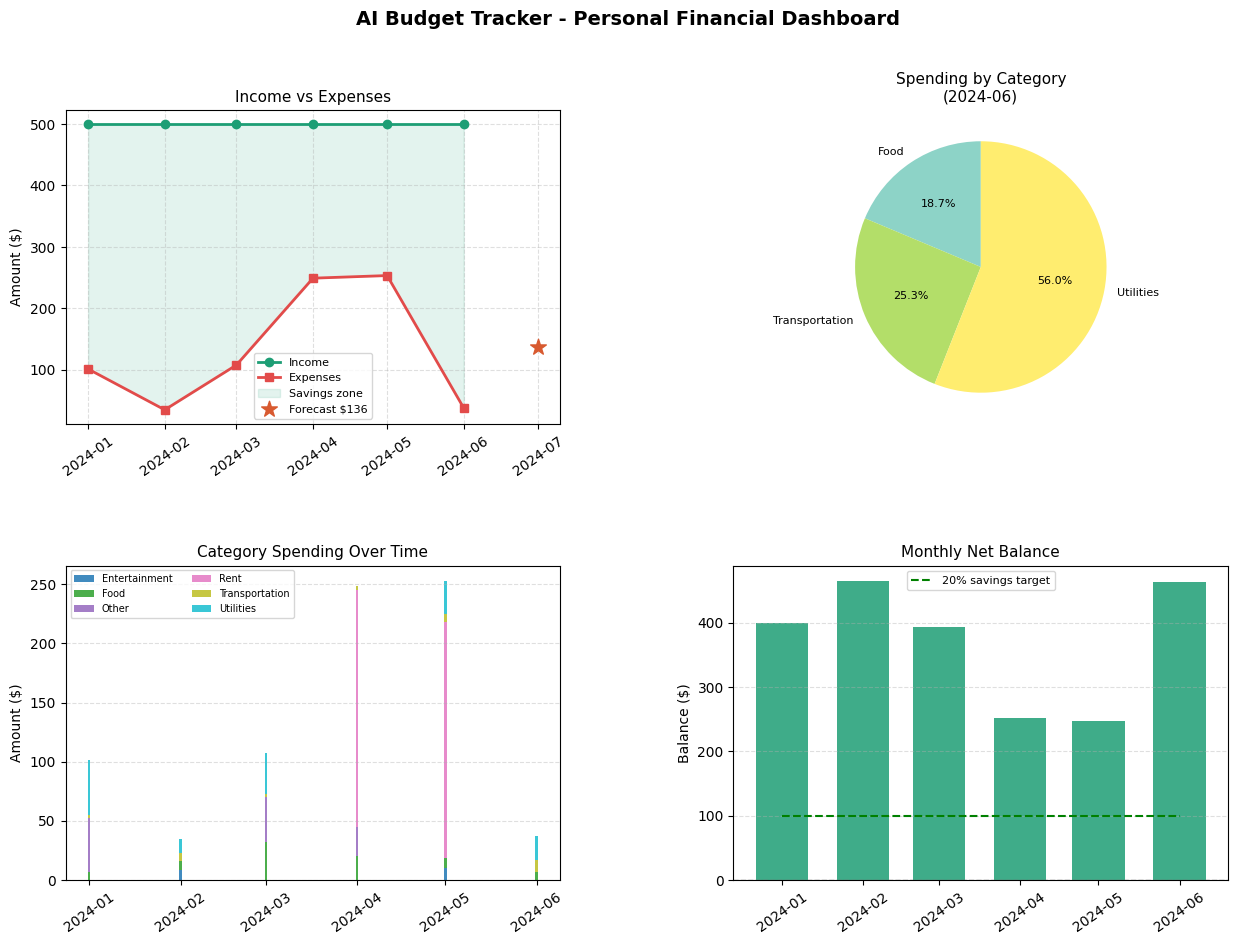

Dashboard saved as pipeline_dashboard.png


In [45]:
# Cell 17: Step 6 - Display Results with Tables and Charts
ICON = {'OVERSPENDING': '[!]', 'WARNING': '[~]', 'OK': '[ok]'}

print(f'Insight Table - {latest_month_str}')
print(f"  {'Category':<16} {'Amount':>9} {'% Income':>9} {'Limit':>7} {'Status':>8}")
print('  ' + '-'*53)
for _, r in insight_df.iterrows():
    print(f"  {r['Category']:<16} ${r['Amount']:>8,.2f} {r['Pct_Income']:>8.1f}% {r['Limit_Pct']:>6}%  {ICON.get(r['Status'],''):>5}")
print()

fig = plt.figure(figsize=(15, 10))
fig.suptitle('AI Budget Tracker - Personal Financial Dashboard', fontsize=14, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
months_dt = monthly['month_dt']

# Panel 1: Income vs Expenses + Forecast
ax1.plot(months_dt, monthly['total_income'],   'o-', color='#1D9E75', lw=2, label='Income',   markersize=6)
ax1.plot(months_dt, monthly['total_expenses'], 's-', color='#E24B4A', lw=2, label='Expenses', markersize=6)
ax1.fill_between(months_dt, monthly['total_expenses'], monthly['total_income'],
                 alpha=0.12, color='#1D9E75', label='Savings zone')
ax1.scatter([next_month], [next_pred], color='#D85A30', s=140, zorder=5,
            marker='*', label=f'Forecast ${next_pred:.0f}')
ax1.set_title('Income vs Expenses', fontsize=11)
ax1.set_ylabel('Amount ($)')
ax1.legend(fontsize=8)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.tick_params(axis='x', rotation=35)

# Panel 2: Category pie - latest month
cat_vals   = cat_series[cat_series > 0]
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(cat_vals)))
ax2.pie(cat_vals.values, labels=cat_vals.index, autopct='%1.1f%%',
        colors=colors_pie, startangle=90, textprops={'fontsize': 8})
ax2.set_title(f'Spending by Category\n({latest_month_str})', fontsize=11)

# Panel 3: Category stacked bar over time
bottom     = np.zeros(len(monthly_cat))
colors_bar = plt.cm.tab10(np.linspace(0, 1, len(monthly_cat.columns)))
for j, cat in enumerate(monthly_cat.columns):
    ax3.bar(monthly_cat.index, monthly_cat[cat], bottom=bottom,
            label=cat, color=colors_bar[j], alpha=0.85)
    bottom += monthly_cat[cat].values
ax3.set_title('Category Spending Over Time', fontsize=11)
ax3.set_ylabel('Amount ($)')
ax3.legend(fontsize=7, ncol=2)
ax3.grid(True, axis='y', linestyle='--', alpha=0.4)
ax3.tick_params(axis='x', rotation=35)

# Panel 4: Net Balance + savings target
bar_colors   = ['#1D9E75' if v >= 0 else '#E24B4A' for v in monthly['net_balance']]
ax4.bar(months_dt, monthly['net_balance'], color=bar_colors, alpha=0.85, width=20)
ax4.axhline(0, color='#888', lw=1.0, linestyle='--')
savings_line = monthly['total_income'] * (SAVINGS_RULE / 100)
ax4.plot(months_dt, savings_line, 'g--', lw=1.5, label=f'{SAVINGS_RULE}% savings target')
ax4.set_title('Monthly Net Balance', fontsize=11)
ax4.set_ylabel('Balance ($)')
ax4.legend(fontsize=8)
ax4.grid(True, axis='y', linestyle='--', alpha=0.4)
ax4.tick_params(axis='x', rotation=35)

plt.savefig('pipeline_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved as pipeline_dashboard.png')

---
## Final Pipeline Summary

In [46]:
# Cell 19: Final Pipeline Summary
print('=' * 60)
print('  AI BUDGET TRACKER - PIPELINE SUMMARY')
print('  (ITM-360 AI Research Proposal - Aligned)')
print('=' * 60)
print(f'  Records : {len(df_raw)}  ({len(expense_df)} expense | {len(income_df)} income)')
print(f'  Dates   : {df_raw["date"].min().date()} to {df_raw["date"].max().date()}')
print(f'  Months  : {len(monthly)}')
print()
print('  [Model 1] Expense Classification')
print('    Type       : TF-IDF + Logistic Regression (Knowledge-Based AI)')
print(f'    Categories : {sorted(expense_df["category"].unique())}')
print()
print('  [Model 2] Spending Prediction (On-Demand Per-User)')
print(f'    Algorithm  : {"Weighted Recent" if best_model_name == "WT" else "Rolling Average"}  window={best_window}')
print(f'    MAE        : ${best_mae:.2f}')
print(f'    Forecast   : ${next_pred:.2f} for {next_month.strftime("%Y-%m")}  ({trend})')
print()
print('  [Model 3] Financial Insights (Rule-Based Inference)')
ICON = {'OVERSPENDING': '[!]', 'WARNING': '[~]', 'OK': '[ok]'}
for _, row in insight_df.iterrows():
    print(f'    {ICON.get(row["Status"], "")} {row["Category"]}: {row["Insight"]}')
print()
print('  Net Balance Summary (latest month):')
print(f'    Total Income   : ${total_income_m:,.2f}')
print(f'    Total Expenses : ${total_expense_m:,.2f}')
print(f'    Net Balance    : ${net_balance_m:,.2f}')
print('=' * 60)

  AI BUDGET TRACKER - PIPELINE SUMMARY
  (ITM-360 AI Research Proposal - Aligned)
  Records : 42  (36 expense | 6 income)
  Dates   : 2024-01-01 to 2024-06-30
  Months  : 6

  [Model 1] Expense Classification
    Type       : TF-IDF + Logistic Regression (Knowledge-Based AI)
    Categories : ['Entertainment', 'Food', 'Other', 'Rent', 'Transportation', 'Utilities']

  [Model 2] Spending Prediction (On-Demand Per-User)
    Algorithm  : Rolling Average  window=5
    MAE        : $111.56
    Forecast   : $136.35 for 2024-07  (Stable)

  [Model 3] Financial Insights (Rule-Based Inference)
    [ok] Food: Food spending is healthy at 1.4% of income (limit: 25%).
    [ok] Transportation: Transportation spending is healthy at 1.9% of income (limit: 15%).
    [ok] Utilities: Utilities spending is healthy at 4.2% of income (limit: 10%).
    [ok] Savings: Great! Saving 92.5% of income, meeting the recommended 20% minimum.

  Net Balance Summary (latest month):
    Total Income   : $500.00
    Total